In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
"""

# cut the datasets to 20000 rows

# Read the CSVs (adjust paths if needed)
training_set_VU_DM = pd.read_csv("datasets/training_set_VU_DM.csv")
test_set_VU_DM = pd.read_csv("datasets/test_set_VU_DM.csv")

# Cut at index 20000
train_cut = training_set_VU_DM.iloc[:20000]
test_cut = test_set_VU_DM.iloc[:20000]

# Create folder if it doesn't exist
os.makedirs("datasets", exist_ok=True)

# Save to CSV
train_cut.to_csv("datasets/training_set_VU_DM_reduced.csv", index=False)
test_cut.to_csv("datasets/test_set_VU_DM_reduced.csv", index=False)

"""

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load & filter (outliers)
df = pd.read_csv("./datasets/training_set_VU_DM_reduced.csv")
# define percentiles
p_lower, p_upper = df['price_usd'].quantile([0.1, 0.9])
d_lower, d_upper = df['orig_destination_distance'].quantile([0.1, 0.9])
# filter
mask = (
    df['price_usd'].between(p_lower, p_upper) &
    df['orig_destination_distance'].between(d_lower, d_upper)
)
filtered = df[mask].copy()
orig_filtered = filtered.copy()   # for fair before/after comparison

# 2. Missing‐flagging
to_impute = ['visitor_hist_starrating',
             'visitor_hist_adr_usd',
             'prop_review_score',
             'price_usd']
for col in to_impute + ['orig_destination_distance']:
    filtered[f"{col}_missing"] = filtered[col].isnull().astype(int)

# 3. Distribution‐preserving imputation
rng = np.random.default_rng(42)
for col in to_impute:
    non_null = filtered[col].dropna().values
    n_missing = filtered[col].isnull().sum()
    sampled = rng.choice(non_null, size=n_missing, replace=True)
    filtered.loc[filtered[col].isnull(), col] = sampled

# distance: fill unknown with -1
filtered['orig_destination_distance'].fillna(-1, inplace=True)

# 4. Recompute derived features
filtered['price_diff_from_history'] = filtered['price_usd'] - filtered['visitor_hist_adr_usd']
filtered['starrating_diff']      = filtered['prop_starrating'] - filtered['visitor_hist_starrating']
filtered['price_rank']           = filtered.groupby('srch_id')['price_usd'].rank()
filtered['location_score1_rank'] = filtered.groupby('srch_id')['prop_location_score1'].rank(pct=True)
filtered['booking_or_click']     = filtered['booking_bool'] + 0.15 * filtered['click_bool']

# 5. Plot overlays for imputed columns
def plot_overlay(orig, proc, title, xlabel):
    plt.figure(figsize=(8,4))
    orig.dropna().plot.kde(label='Filtered Original', linestyle='--')
    proc.dropna().plot.kde(label='Imputed (sampled)', linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.legend()
    plt.show()

plot_overlay(orig_filtered['visitor_hist_adr_usd'], 
             filtered['visitor_hist_adr_usd'],
             "Visitor ADR: Original vs Sample‐Imputed",
             "visitor_hist_adr_usd")

plot_overlay(orig_filtered['prop_review_score'],
             filtered['prop_review_score'],
             "Prop Review Score: Original vs Sample‐Imputed",
             "prop_review_score")

plot_overlay(orig_filtered['price_usd'],
             filtered['price_usd'],
             "Price USD: Original vs Sample‐Imputed",
             "price_usd")

# 6. Plot engineered‐feature distributions
plt.figure(figsize=(8,4))
filtered['price_diff_from_history'].hist(bins=100, edgecolor='black')
plt.title("Price Difference from Visitor History")
plt.xlabel("price_diff_from_history")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
filtered['starrating_diff'].hist(bins=10, edgecolor='black')
plt.title("Star Rating Difference from Visitor History")
plt.xlabel("starrating_diff")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
filtered['location_score1_rank'].hist(bins=20, edgecolor='black')
plt.title("Location Score1 Rank (Percentile)")
plt.xlabel("location_score1_rank")
plt.ylabel("Frequency")
plt.show()

# 7. Summary statistics & correlations
print("=== Engineered Feature Summary ===\n")
print(filtered[['price_diff_from_history', 'starrating_diff', 'location_score1_rank']].describe())

print("\n=== Correlation with booking_or_click ===\n")
print(filtered[['price_diff_from_history', 'starrating_diff', 'location_score1_rank', 'booking_or_click']]
      .corr()['booking_or_click'])

# 8. drop features that contain to many missing values
def handle_missing_data(df):
    # Competitor columns
    inv_cols  = [f'comp{i}_inv' for i in range(1, 9)]
    rate_cols = [f'comp{i}_rate' for i in range(1, 9)]
    pct_cols  = [f'comp{i}_rate_percent_diff' for i in range(1, 9)]
    
    # 1) Inventory: fill NaN → 0, and replace -1 → 0
    df[inv_cols] = df[inv_cols].fillna(0).replace(-1, 0)
    
    # 2) Rates: fill NaN → 0
    df[rate_cols] = df[rate_cols].fillna(0)
    
    # 3) Percent diffs: fill NaN → 0, then multiply by the (now filled) rates
    df[pct_cols] = df[pct_cols].fillna(0).multiply(df[rate_cols], axis=0)
    
    # 4) Drop the raw rate columns
    df.drop(columns=rate_cols, inplace=True)
    
    # 5) Drop other columns with too many missing values
    to_drop = [
        'gross_bookings_usd',
        'srch_query_affinity_score',
        'visitor_hist_adr_usd',
        'orig_destination_distance',
        'visitor_hist_starrating',
        'prop_location_score2'
    ]
    df.drop(columns=to_drop, errors='ignore', inplace=True)
    
    # 6) Reviews: missing → 0
    df['prop_review_score'] = df['prop_review_score'].fillna(0)
    
    return df




<Axes: >

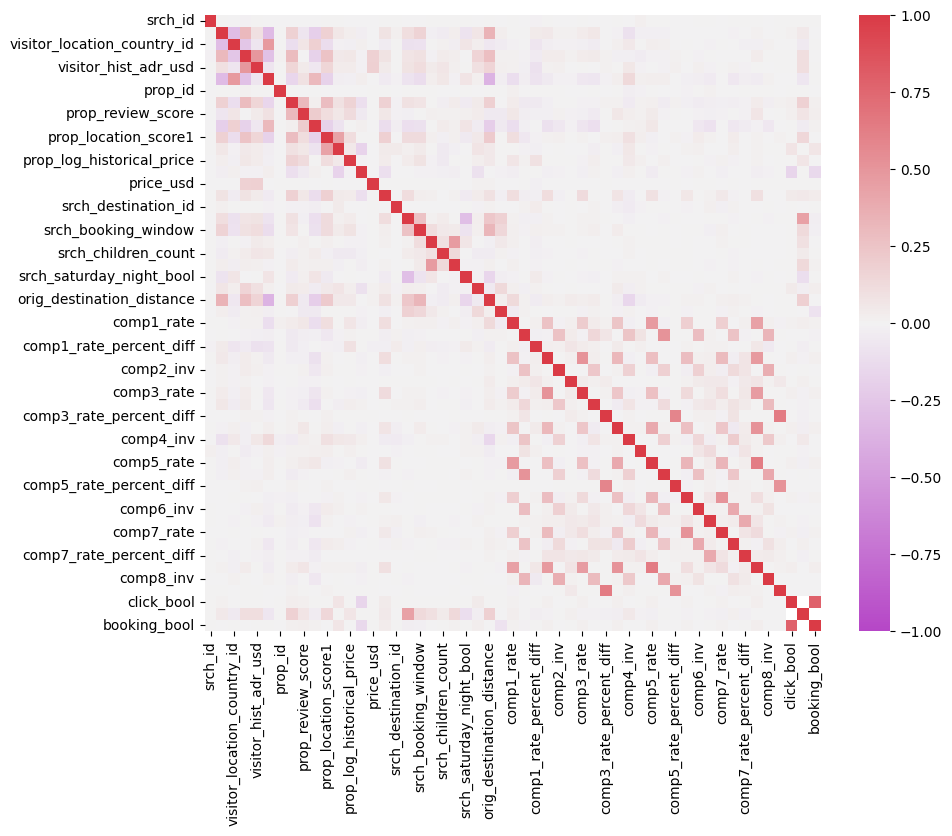

In [4]:
training_data.describe()
f, ax = plt.subplots(figsize=(10, 8))
corr = training_data.corr(numeric_only=True)
sns.heatmap(corr,
    cmap=sns.diverging_palette(300, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax)

Training Set Shape: (4958347, 54)
Test Set Shape: (4959183, 50)

Training Set Columns:
Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_p

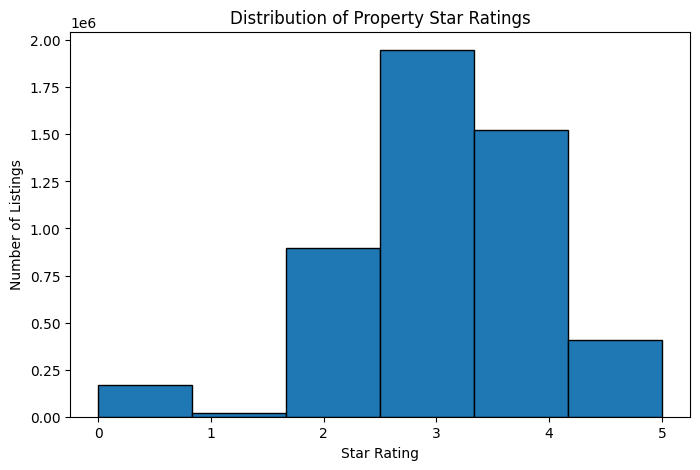

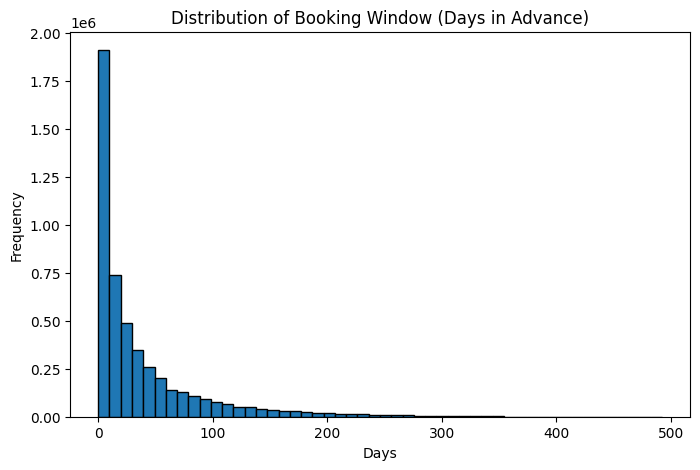

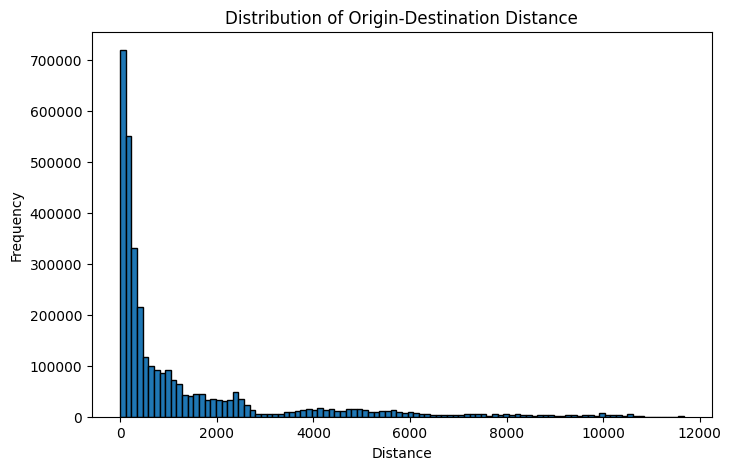

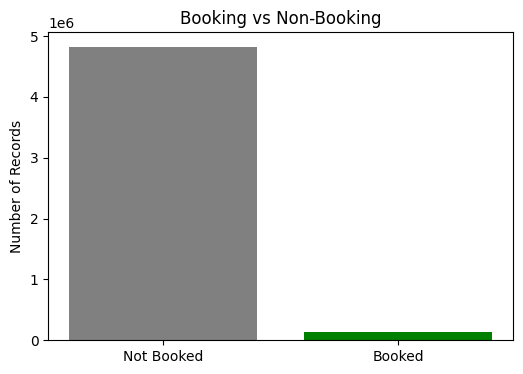

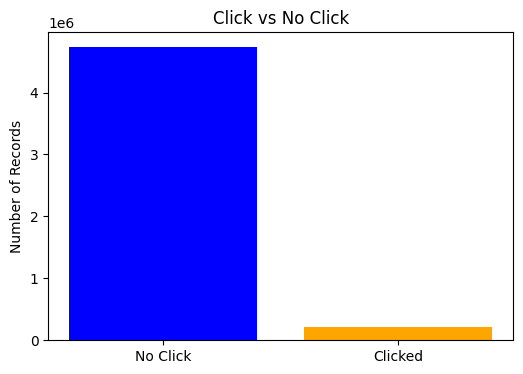

In [ ]:
# Load datasets (make sure the files are in the same directory)
train = pd.read_csv("./data/training_set_VU_DM.csv")
test = pd.read_csv("./data/test_set_VU_DM.csv")

# 1. Basic Info
print("Training Set Shape:", train.shape)
print("Test Set Shape:", test.shape)

print("\nTraining Set Columns:")
print(train.columns)

# 2. Missing Values Summary
missing_values = train.isnull().mean().sort_values(ascending=False) * 100
print("\nMissing Values (% of rows):")
print(missing_values[missing_values > 0])

# 3. Descriptive Statistics
print("\nDescriptive Statistics:")
print(train.describe())

# 4. Plot: Property Star Rating Distribution
plt.figure(figsize=(8, 5))
train['prop_starrating'].hist(bins=6, edgecolor='black')
plt.title("Distribution of Property Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Listings")
plt.grid(False)
plt.show()

# 5. Plot: Search Booking Window
plt.figure(figsize=(8, 5))
train['srch_booking_window'].hist(bins=50, edgecolor='black')
plt.title("Distribution of Booking Window (Days in Advance)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

# 6. Plot: Origin-Destination Distance
plt.figure(figsize=(8, 5))
train['orig_destination_distance'].dropna().hist(bins=100, edgecolor='black')
plt.title("Distribution of Origin-Destination Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

# 7. Plot: Booking vs. Non-Booking
booking_counts = train['booking_bool'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(['Not Booked', 'Booked'], booking_counts.values, color=['grey', 'green'])
plt.title("Booking vs Non-Booking")
plt.ylabel("Number of Records")
plt.show()

# 8. Plot: Click vs. No Click
click_counts = train['click_bool'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(['No Click', 'Clicked'], click_counts.values, color=['blue', 'orange'])
plt.title("Click vs No Click")
plt.ylabel("Number of Records")
plt.show()


In [17]:
training_data = pd.read_csv('data/training_set_VU_DM.csv')



Whenver comp_inv is know, then comp_rate is also known. We sum all the comp_rate and merge into variable, but only if there the other hotel has availability.

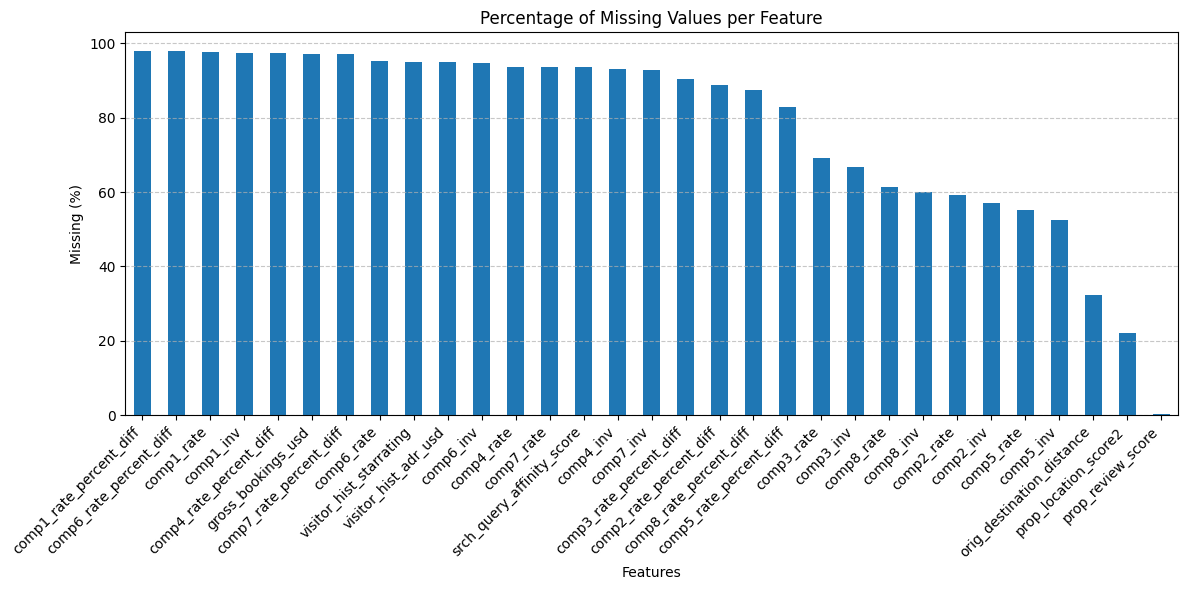

In [18]:
def plot_missing_percentages(df, figsize=(12, 6), top_n=None):
    # Calculate missing value percentages
    missing_percent = df.isnull().mean() * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
    
    if top_n:
        missing_percent = missing_percent.head(top_n)
    
    # Plot
    plt.figure(figsize=figsize)
    missing_percent.plot(kind='bar')
    plt.title('Percentage of Missing Values per Feature')
    plt.ylabel('Missing (%)')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot missing percentages for the top 10 features with missing values
plot_missing_percentages(training_data, top_n=40)

In [34]:
import pandas as pd
import numpy as np

def add_comp_rate_sum(df: pd.DataFrame,
                      comps=range(1, 9),
                      new_col: str = "comp_rate_sum_available",
                      drop_source_cols: bool = False) -> pd.DataFrame:
    """
    Create a single column that sums all comp*_rate values **only** when the
    competitor has availability (comp*_inv == 0).  
    If either variable is missing we treat it as 0 so it doesn’t affect the sum.

    Parameters
    ----------
    df : pd.DataFrame
        Your raw Expedia dataframe.
    comps : iterable, default range(1, 9)
        Which competitor numbers to include (1-8 in the public dataset).
    new_col : str
        Name of the aggregated column that will be added.
    drop_source_cols : bool, default False
        If True, drop the original comp*_rate / comp*_inv columns after building
        the feature.

    Returns
    -------
    pd.DataFrame
        Same DataFrame with the new column added (and optionally reduced).
    """
    # Build a list of Series – one per competitor – to be summed
    rate_terms = []
    for c in comps:
        rate_col = f"comp{c}_rate"
        inv_col  = f"comp{c}_inv"

        if rate_col not in df.columns or inv_col not in df.columns:
            # gracefully skip competitors that aren't present
            continue

        # Competitor considered *available* when comp*_inv == 0
        available_mask = (df[inv_col] == 0)

        # Keep rate value only when available, else 0  (also 0 for NaN)
        term = df[rate_col].where(available_mask, 0).fillna(0)

        rate_terms.append(term)

    # Sum across competitors row-wise
    df[new_col] = np.sum(rate_terms, axis=0).astype(int)

    if drop_source_cols:
        to_drop = [f"comp{c}_{sfx}"
                   for c in comps
                   for sfx in ("rate", "inv")]
        df = df.drop(columns=[col for col in to_drop if col in df.columns])

    return df

# Add the new feature to the training data
training_data = add_comp_rate_sum(training_data, drop_source_cols=True)


# Take mean instead of sum (we can try)
"""
df["comp_num_available"] = (
    (df[[f"comp{c}_inv" for c in comps]] == 0).sum(axis=1)
)
df["comp_rate_mean_available"] = (
    df["comp_rate_sum_available"] / df["comp_num_available"]
).replace([np.inf, -np.inf], np.nan)
"""

'\ndf["comp_num_available"] = (\n    (df[[f"comp{c}_inv" for c in comps]] == 0).sum(axis=1)\n)\ndf["comp_rate_mean_available"] = (\n    df["comp_rate_sum_available"] / df["comp_num_available"]\n).replace([np.inf, -np.inf], np.nan)\n'

In [35]:
correlation = training_data["comp_rate_sum_available"].corr(training_data["booking_bool"])
print(f"Correlation between comp_rate_sum_available and booking_bool: {correlation:.4f}")


Correlation between comp_rate_sum_available and booking_bool: 0.0187


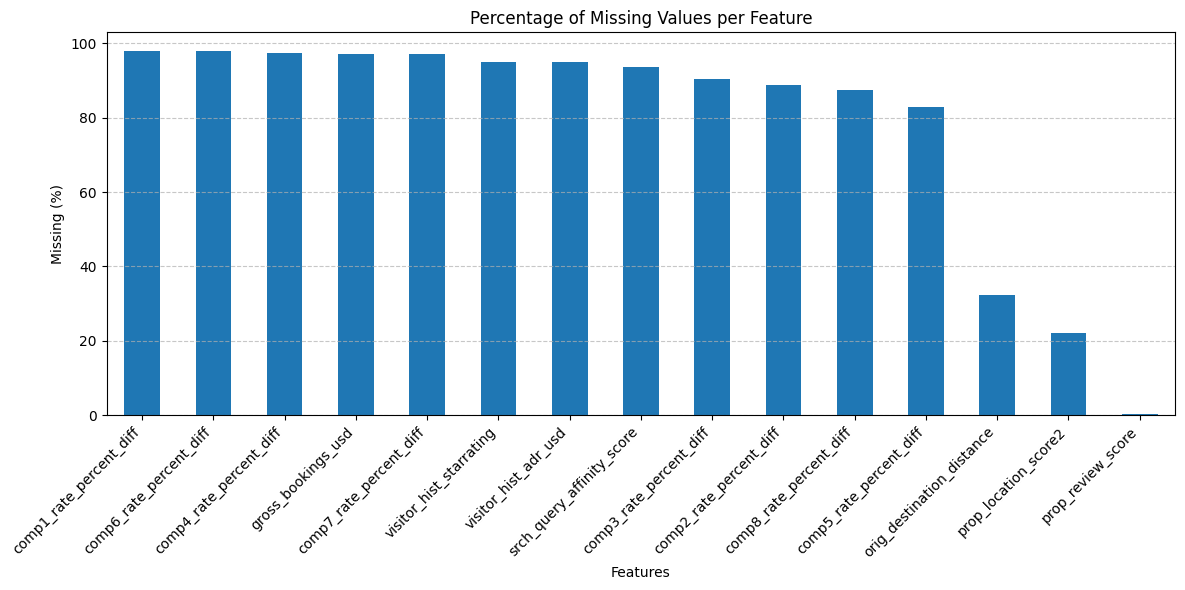

In [21]:
def plot_missing_percentages(df, figsize=(12, 6), top_n=None):
    # Calculate missing value percentages
    missing_percent = df.isnull().mean() * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
    
    if top_n:
        missing_percent = missing_percent.head(top_n)
    
    # Plot
    plt.figure(figsize=figsize)
    missing_percent.plot(kind='bar')
    plt.title('Percentage of Missing Values per Feature')
    plt.ylabel('Missing (%)')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot missing percentages for the top 10 features with missing values
plot_missing_percentages(training_data, top_n=40)

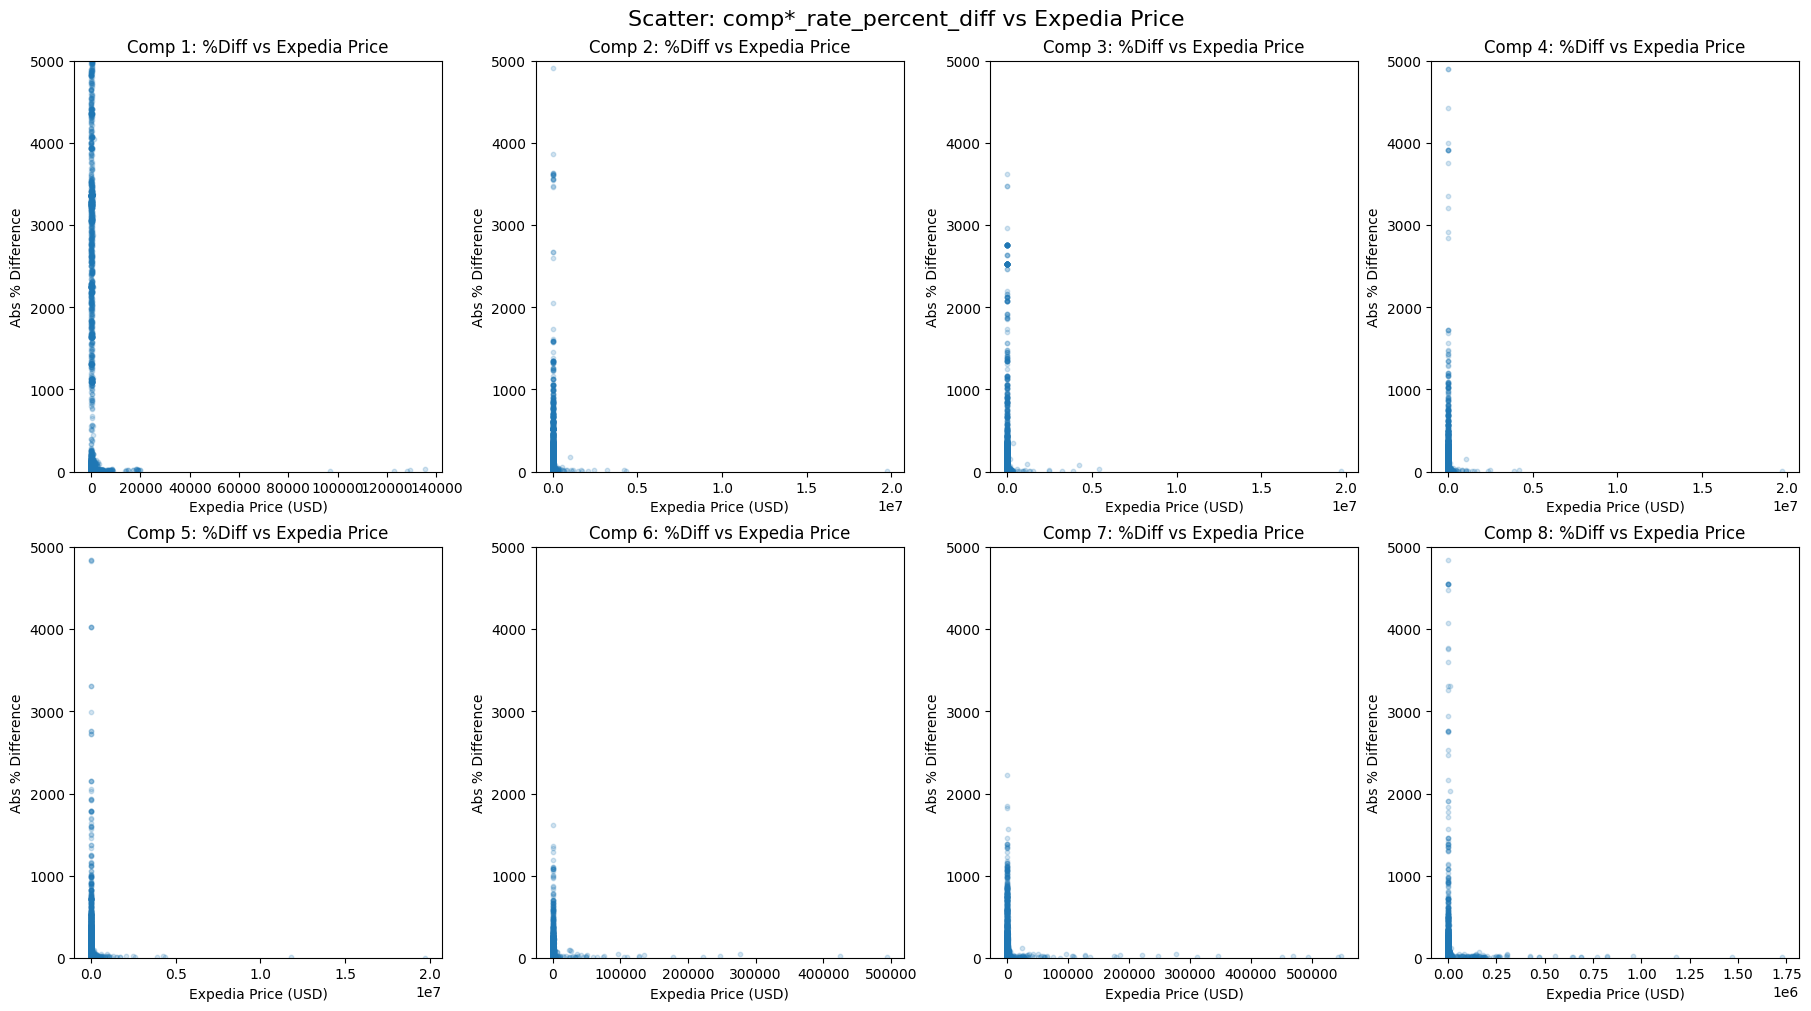

In [32]:
import matplotlib.pyplot as plt

def plot_scatter_price_vs_pctdiff(df, comps=range(1, 9), expedia_price_col="price_usd"):
    """
    For each competitor, plot comp*_rate_percent_diff vs. Expedia price to detect anomalies.
    """
    ncols = 4
    nrows = -(-len(comps) // ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(18, 10), constrained_layout=True)
    axs = axs.flatten()

    for i, c in enumerate(comps):
        pct_col = f"comp{c}_rate_percent_diff"
        if pct_col not in df.columns or expedia_price_col not in df.columns:
            axs[i].set_visible(False)
            continue

        valid = df[[expedia_price_col, pct_col]].dropna()
        if valid.empty:
            axs[i].set_visible(False)
            continue

        axs[i].scatter(valid[expedia_price_col], valid[pct_col], alpha=0.2, s=10)
        axs[i].set_title(f"Comp {c}: %Diff vs Expedia Price")
        axs[i].set_xlabel("Expedia Price (USD)")
        axs[i].set_ylabel("Abs % Difference")
        axs[i].set_ylim(0, 5000)  # Adjust as needed for visibility

    # Hide any unused plots
    for j in range(len(comps), len(axs)):
        axs[j].set_visible(False)

    fig.suptitle("Scatter: comp*_rate_percent_diff vs Expedia Price", fontsize=16)
    plt.show()
plot_scatter_price_vs_pctdiff(training_data, comps=range(1, 9), expedia_price_col="price_usd")

In [ ]:
comp_vars = [i for i in training_data.columns if 'comp' in i]
training_data.loc[training_data.prop_id == 424, comp_vars]



,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,...,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff
81716,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,7.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,7.0
87217,NaN,NaN,NaN,1.0,0.0,6.0,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,19.0
152618,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,6.0
159139,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,...,13.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,13.0
266343,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586058,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,13.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,13.0
4595283,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
4806567,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
4822043,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,4.0


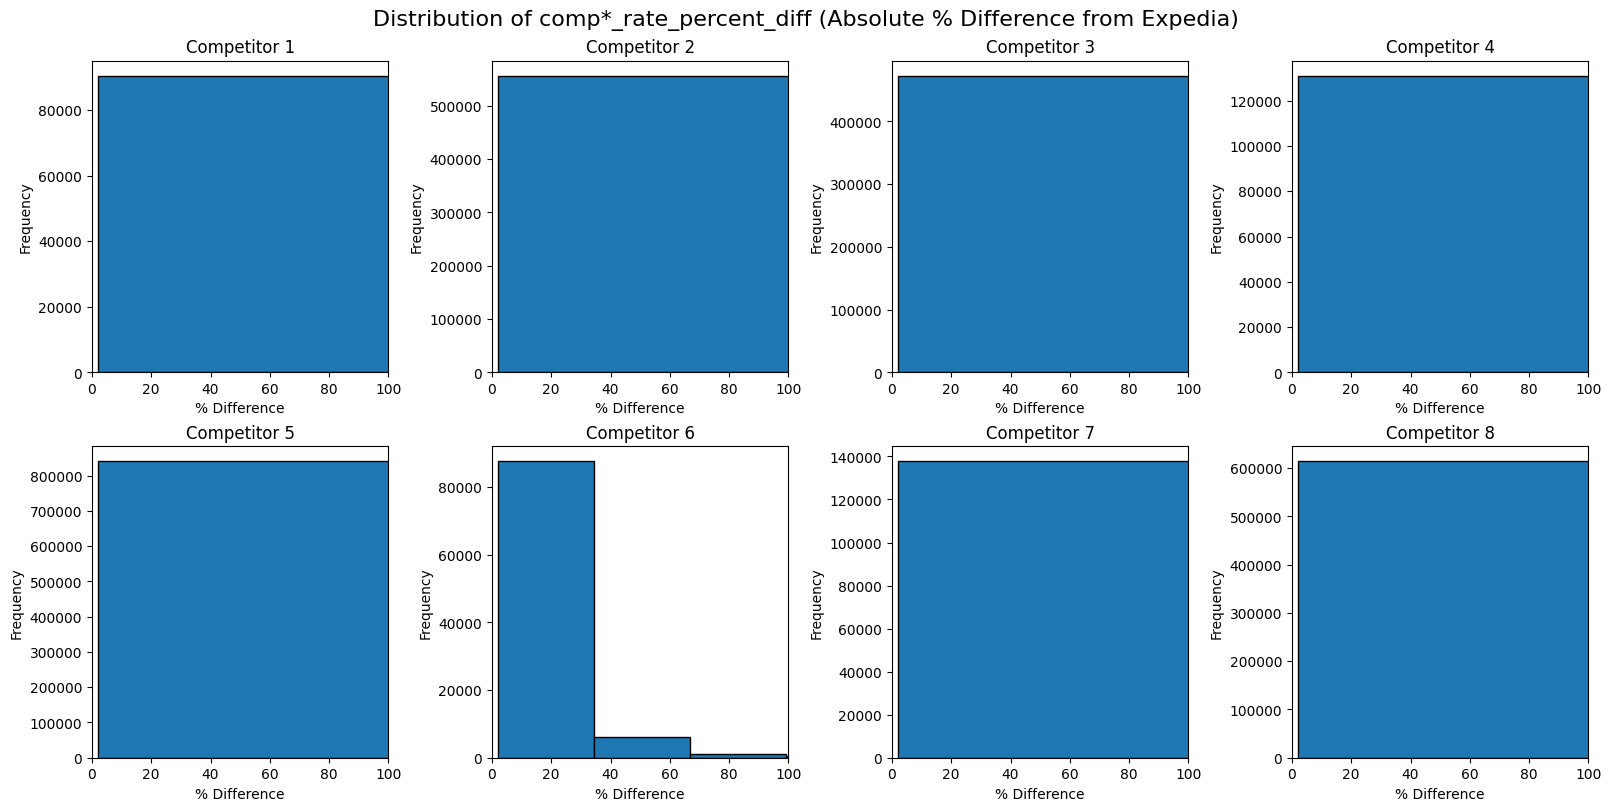

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_comp_rate_percent_diff_distributions(df: pd.DataFrame, comps=range(1, 9)):
    """
    Plots the distribution (histograms) of comp*_rate_percent_diff variables for all competitors.
    Skips missing values and ensures shared axis for comparison.

    Parameters
    ----------
    df : pd.DataFrame
        Your Expedia dataframe.
    comps : iterable
        Competitor indices to plot (default: 1 to 8).
    """
    num_comps = len(comps)
    ncols = 4
    nrows = -(-num_comps // ncols)  # ceiling division

    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 8), constrained_layout=True)
    axs = axs.flatten()

    for i, c in enumerate(comps):
        col = f"comp{c}_rate_percent_diff"
        if col not in df.columns:
            axs[i].set_visible(False)
            continue

        clean_vals = df[col].dropna()

        axs[i].hist(clean_vals, bins=50, edgecolor='black')
        axs[i].set_title(f"Competitor {c}")
        axs[i].set_xlabel("% Difference")
        axs[i].set_ylabel("Frequency")
        axs[i].set_xlim(0, min(100, clean_vals.max()))  # cut off outliers

    # Hide unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    fig.suptitle("Distribution of comp*_rate_percent_diff (Absolute % Difference from Expedia)", fontsize=16)
    plt.show()

plot_comp_rate_percent_diff_distributions(training_data)



In [20]:
import pandas as pd
import numpy as np

def split_date_time(date_time):
    """
    Splits a datetime object or string into year, month, day, hour, minute, second.

    Parameters:
        date_time (datetime or str or None): The input datetime.

    Returns:
        dict: Dictionary with keys 'year', 'month', 'day', 'hour', 'minute', 'second' if valid,
              otherwise a dictionary with None values.
    """
    if date_time is None or pd.isna(date_time):
        return {
            'year': None,
            'month': None,
            'day': None,
            'hour': None,
            'minute': None,
            'second': None
        }

    # Parse if it's a string
    if isinstance(date_time, str):
        try:
            date_time = pd.to_datetime(date_time)
        except Exception:
            return {
                'year': None,
                'month': None,
                'day': None,
                'hour': None,
                'minute': None,
                'second': None
            }

    return {
        'year': date_time.year,
        'month': date_time.month,
        'day': date_time.day,
        'hour': date_time.hour,
        'minute': date_time.minute,
        'second': date_time.second
    }
split_date_time(training_data)

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
def plot_missing_percentages(df, figsize=(12, 6), top_n=None):
    # Calculate missing value percentages
    missing_percent = df.isnull().mean() * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
    
    if top_n:
        missing_percent = missing_percent.head(top_n)
    
    # Plot
    plt.figure(figsize=figsize)
    missing_percent.plot(kind='bar')
    plt.title('Percentage of Missing Values per Feature')
    plt.ylabel('Missing (%)')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot missing percentages for the top 10 features with missing values
plot_missing_percentages(training_data, top_n=40)

In [ ]:
import numpy as np
import pandas as pd

def impute_comp_inv(df: pd.DataFrame,
                    comps=range(1, 8 + 1),
                    hotel_key="hotel_id",
                    default_if_unknown=0):
    """
    Fill missing comp*_inv values with the most likely value.

    Logic
    -----
    1.  For each competitor N we look at all rows that share the same
        `hotel_key` (usually *hotel_id*).  If at least one of those rows
        **does** contain a non-null `compN_inv`, we take the *mode*
        (most frequent) value in that mini-group and use it to fill
        **every** NaN in that group.

    2.  If the whole hotel-group is NaN for this competitor, we fall back to
        the *global* mode across the entire data set for that competitor.

    3.  If even the global mode doesn’t exist (very rare—means the column is
        entirely NaN), we use `default_if_unknown` (by business convention,
            0 = “has availability”).

    Parameters
    ----------
    df : pd.DataFrame
        Expedia data frame.
    comps : iterable of int
        Competitor numbers to process (default 1–8).
    hotel_key : str
        Column that identifies the *entity* for which availability is likely
        stable (usually "hotel_id"; could also be "prop_id" or a cluster id).
    default_if_unknown : {0, 1}
        Final fall-back value when no information is available anywhere.

    Returns
    -------
    pd.DataFrame
        Same frame but with `comp*_inv` NaNs imputed.
    """
    out = df.copy()

    for n in comps:
        inv_col = f"comp{n}_inv"
        if inv_col not in out.columns:
            continue  # skip silently if that competitor is missing

        # ── 1) per-hotel mode ────────────────────────────────────────────────
        hotel_mode = (
            out.groupby(hotel_key)[inv_col]
               .apply(lambda s: s.mode(dropna=True).iloc[0]
                                 if not s.mode(dropna=True).empty
                                 else np.nan)
        )

        # map hotel-level expectation back onto rows
        out[inv_col] = out[inv_col].fillna(
            out[hotel_key].map(hotel_mode)
        )

        # ── 2) global mode fallback ─────────────────────────────────────────
        if out[inv_col].isna().any():
            global_mode = (
                out[inv_col].mode(dropna=True).iloc[0]
                if not out[inv_col].mode(dropna=True).empty
                else np.nan
            )
            out[inv_col] = out[inv_col].fillna(global_mode)

        # ── 3) absolute fallback when everything was NaN ────────────────────
        out[inv_col] = out[inv_col].fillna(default_if_unknown)

        # ensure we keep the canonical {0,1} coding
        out[inv_col] = out[inv_col].astype(int)

    return out
